## Digital Marketing Campaign Conversion Prediction

### End-to-End Data Science, Machine Learning & Artificial Intelligence Project

## Problem Statement
Digital marketing campaigns often suffer from inefficient budget allocation due to limited visibility into which users are most likely to convert.
Targeting all users equally leads to wasted ad spend on low-intent audiences and missed opportunities to engage high-intent users.

The challenge is to accurately predict customer conversions using demographic and engagement data, while producing reliable probabilities that can be used directly for campaign decision-making.

## Business Objective
The primary business objective of this project is to build a robust and production-ready conversion prediction model that:
- Identifies users most likely to convert
- Enables smarter audience targeting and bid optimization
- Improves return on advertising spend (ROAS)
- Supports decision-making through interpretable and well-calibrated predictions
The model must balance revenue growth (high recall) with cost efficiency (high precision).

## Executive Decision Summary
This project developed an end-to-end machine learning solution to predict customer conversions for digital marketing campaigns.
Multiple classification models were evaluated using cross-validated F1 score to ensure robust and leakage-free model selection.

The final model, XGBoost, was selected based on superior precision–recall performance, stable probability calibration, and strong generalization under class imbalance.
Explainability was incorporated using SHAP to provide transparency into key conversion drivers, enabling trust and actionable insights for marketing stakeholders.

Additionally, business-driven threshold optimization was applied to align model decisions with marketing cost and revenue objectives, making the solution deployment-ready.

### Key Outcomes
**Improved Targeting Accuracy:** The model effectively distinguishes high-intent users, reducing wasted ad spend on low-probability converters.

**Robust Model Selection:** Cross-validated F1 comparison ensured stable and reliable performance across multiple data splits.

**Explainable Predictions (SHAP):** SHAP analysis identified the most influential features driving conversions, supporting campaign strategy refinement and stakeholder trust.

**Reliable Probability Estimates:** Calibration analysis confirmed that predicted probabilities closely reflect actual conversion rates, enabling accurate ROAS forecasting and bid strategies.

**Business-Aligned Decision Threshold:** Classification thresholds were optimized using precision–recall trade-offs to balance customer acquisition volume with cost efficiency.

**Production Readiness:** The final pipeline integrates preprocessing, imbalance handling, modeling, explainability, and evaluation in a reproducible and scalable framework.

## 1. Data Collection

The dataset contains customer demographic attributes, campaign characteristics, and engagement metrics collected from digital marketing campaigns. The target variable is Conversion, indicating whether a customer converted after campaign exposure.

## Step 1: Import Libraries

We import essential Python libraries for:
- Data manipulation (pandas, numpy)
- Visualization (matplotlib, seaborn)
- Machine learning (scikit-learn)
- Model evaluation and deployment

In [1]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test & CV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    precision_recall_curve
)

# Imbalance handling
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.calibration import calibration_curve

# Explainability
!pip install shap
import shap

# Model Saving
import joblib

# Settings
sns.set(style="whitegrid")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## Step 2: Load the Dataset

The dataset is loaded using pandas.
We verify that the data is loaded correctly by inspecting the first few rows.

In [2]:
df = pd.read_csv("digital_marketing_campaign_dataset.csv")

## Step 3: Data Inspection

Understanding the structure of the dataset helps identify:
- Understand Data types
- Identify Missing values
- Irrelevant or redundant features

In [3]:
df.head()

,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


**Observation:**  
The dataset contains both numerical and categorical features, along with the target variable `Conversion`.

In [4]:
df.shape

(8000, 20)

In [5]:
df.dtypes

CustomerID               int64
Age                      int64
Gender                  object
Income                   int64
CampaignChannel         object
CampaignType            object
AdSpend                float64
ClickThroughRate       float64
ConversionRate         float64
WebsiteVisits            int64
PagesPerVisit          float64
TimeOnSite             float64
SocialShares             int64
EmailOpens               int64
EmailClicks              int64
PreviousPurchases        int64
LoyaltyPoints            int64
AdvertisingPlatform     object
AdvertisingTool         object
Conversion               int64
dtype: object

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           8000 non-null   int64  
 1   Age                  8000 non-null   int64  
 2   Gender               8000 non-null   object 
 3   Income               8000 non-null   int64  
 4   CampaignChannel      8000 non-null   object 
 5   CampaignType         8000 non-null   object 
 6   AdSpend              8000 non-null   float64
 7   ClickThroughRate     8000 non-null   float64
 8   ConversionRate       8000 non-null   float64
 9   WebsiteVisits        8000 non-null   int64  
 10  PagesPerVisit        8000 non-null   float64
 11  TimeOnSite           8000 non-null   float64
 12  SocialShares         8000 non-null   int64  
 13  EmailOpens           8000 non-null   int64  
 14  EmailClicks          8000 non-null   int64  
 15  PreviousPurchases    8000 non-null   i

In [7]:
df.describe()

,CustomerID,Age,Income,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Conversion
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,11999.50000,43.625500,84664.196750,5000.944830,0.154829,0.104389,24.751625,5.549299,7.727718,49.799750,9.476875,4.467375,4.485500,2490.268500,0.876500
std,2309.54541,14.902785,37580.387945,2838.038153,0.084007,0.054878,14.312269,2.607358,4.228218,28.901165,5.711111,2.856564,2.888093,1429.527162,0.329031
min,8000.00000,18.000000,20014.000000,100.054813,0.010005,0.010018,0.000000,1.000428,0.501669,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9999.75000,31.000000,51744.500000,2523.221165,0.082635,0.056410,13.000000,3.302479,4.068340,25.000000,5.000000,2.000000,2.000000,1254.750000,1.000000
50%,11999.50000,43.000000,84926.500000,5013.440044,0.154505,0.104046,25.000000,5.534257,7.682956,50.000000,9.000000,4.000000,4.000000,2497.000000,1.000000
75%,13999.25000,56.000000,116815.750000,7407.989369,0.228207,0.152077,37.000000,7.835756,11.481468,75.000000,14.000000,7.000000,7.000000,3702.250000,1.000000
max,15999.00000,69.000000,149986.000000,9997.914781,0.299968,0.199995,49.000000,9.999055,14.995311,99.000000,19.000000,9.000000,9.000000,4999.000000,1.000000


**Observation:**  
- Numerical features have varying scales → scaling required.
- Dataset suitable for supervised classification.

In [8]:
df.duplicated().sum()

np.int64(0)

## Step 4: Handle Missing Values

Missing values can negatively impact model performance.
In this dataset, missing values (if any) are handled using:
- Mean for numerical features
- Mode for categorical features

In [9]:
df.isnull().sum()

CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64

**Observation:** 
This dataset has no missing values.

## Step 5: Drop Irrelevant Columns

Columns such as unique identifiers do not contribute to prediction.
They are removed to prevent noise and data leakage.

In [10]:
df.drop(columns=['CustomerID'], inplace=True)

**Observation:**  
CustomerID removed to prevent overfitting and leakage.

In [11]:
df.head()

,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,56,Female,136912,Social Media,Awareness,6497.870068,0.043919,0.088031,0,2.399017,7.396803,19,6,9,4,688,IsConfid,ToolConfid,1
1,69,Male,41760,Email,Retention,3898.668606,0.155725,0.182725,42,2.917138,5.352549,5,2,7,2,3459,IsConfid,ToolConfid,1
2,46,Female,88456,PPC,Awareness,1546.429596,0.277490,0.076423,2,8.223619,13.794901,0,11,2,8,2337,IsConfid,ToolConfid,1
3,32,Female,44085,PPC,Conversion,539.525936,0.137611,0.088004,47,4.540939,14.688363,89,2,2,0,2463,IsConfid,ToolConfid,1
4,60,Female,83964,PPC,Conversion,1678.043573,0.252851,0.109940,0,2.046847,13.993370,6,6,6,8,4345,IsConfid,ToolConfid,1


## Step 6: Exploratory Data Analysis (EDA)

EDA helps understand:
- Feature distributions
- Relationships between variables
- Patterns affecting customer conversion

### Conversion Distribution

#### Target Variable: Conversion

Conversion is a binary variable:
- 1 → Converted
- 0 → Not Converted

Marketing datasets are often imbalanced, meaning fewer users convert.
This affects model evaluation and metric selection.

In [12]:
df['Conversion'].value_counts()

Conversion
1    7012
0     988
Name: count, dtype: int64

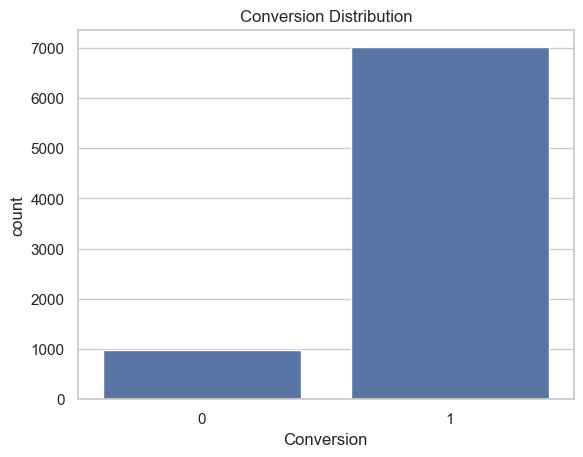

In [13]:
sns.countplot(x='Conversion', data=df)
plt.title("Conversion Distribution")
plt.show()

**Observation:**  
Class imbalance detected. F1-score is more appropriate than accuracy.

## Numerical vs Target

In [14]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.drop('Conversion')

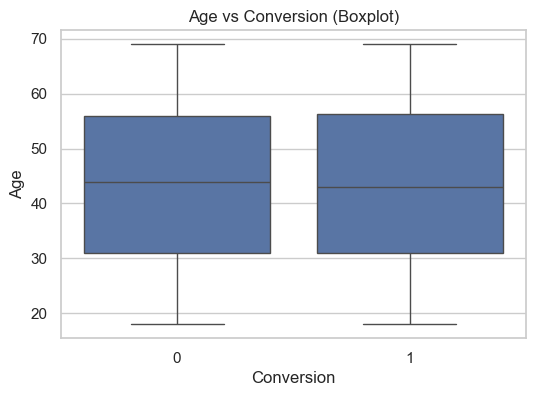

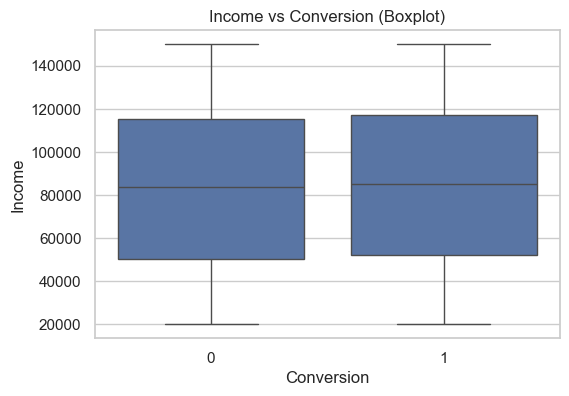

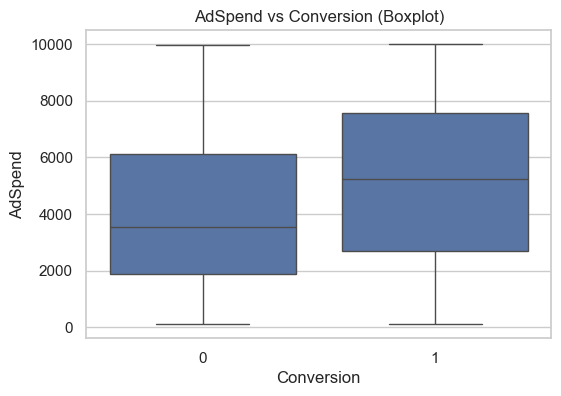

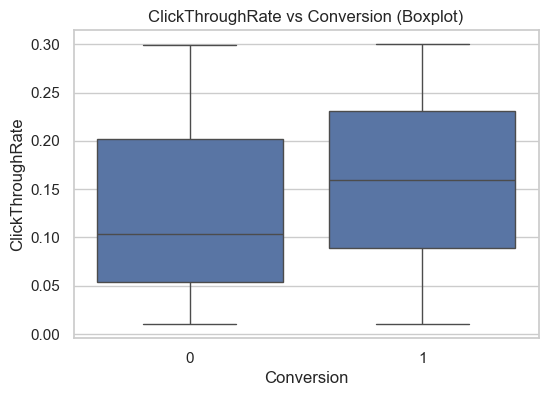

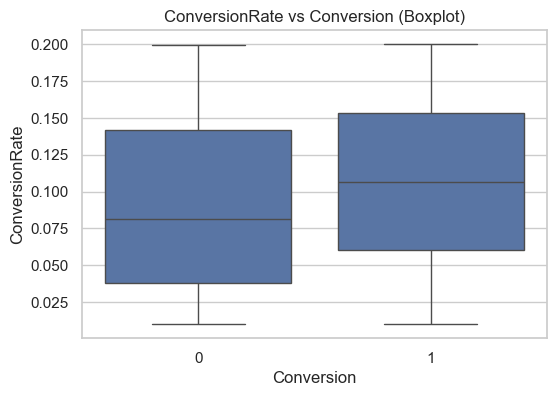

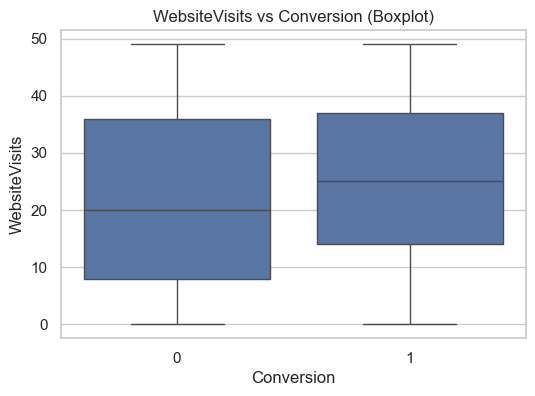

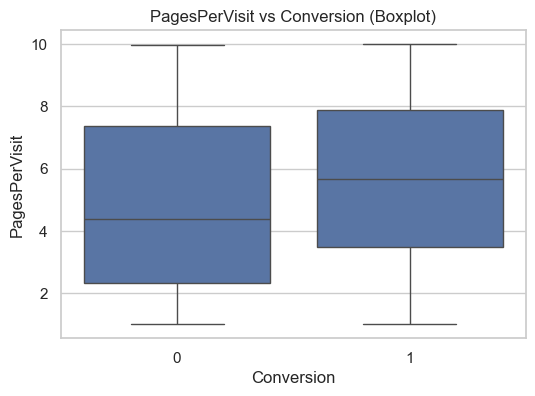

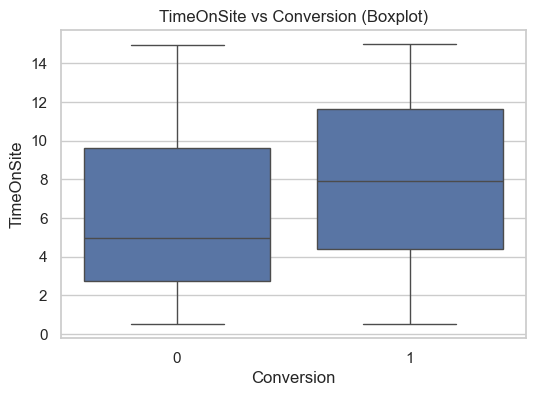

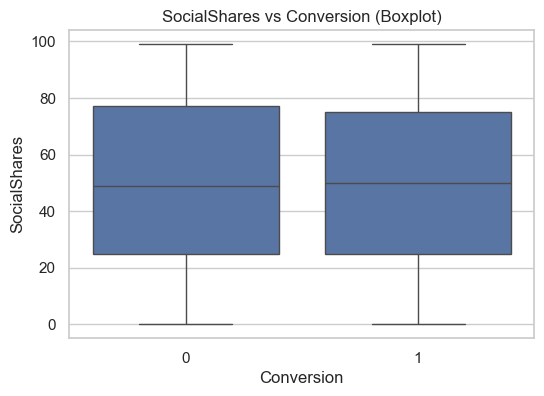

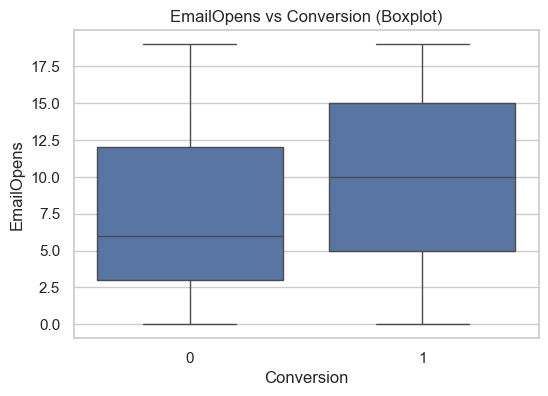

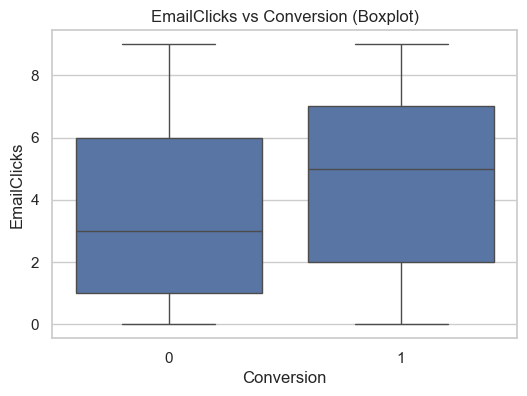

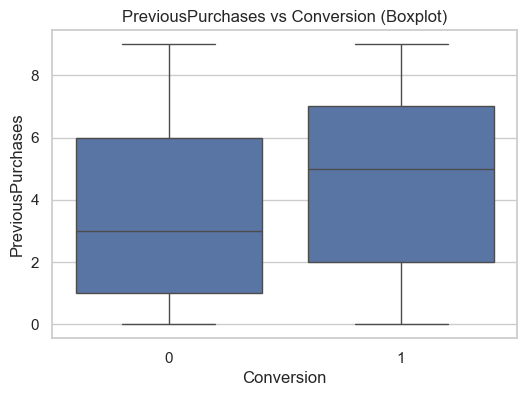

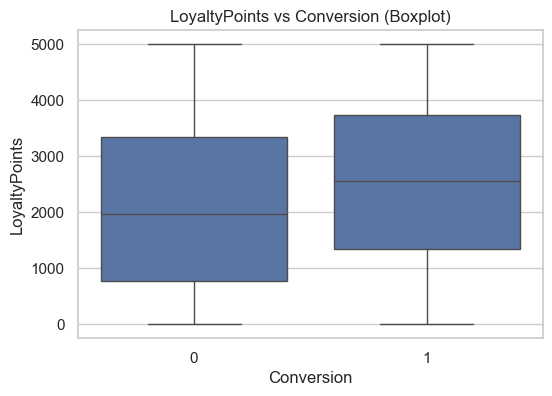

In [15]:

for col in numeric_cols:
    if col != 'Converted':
        plt.figure(figsize=(6,4))
        sns.boxplot(x='Conversion', y=col, data=df)
    plt.title(f'{col} vs Conversion (Boxplot)')
    plt.show()

### Conversion Rate by Campaign Channel

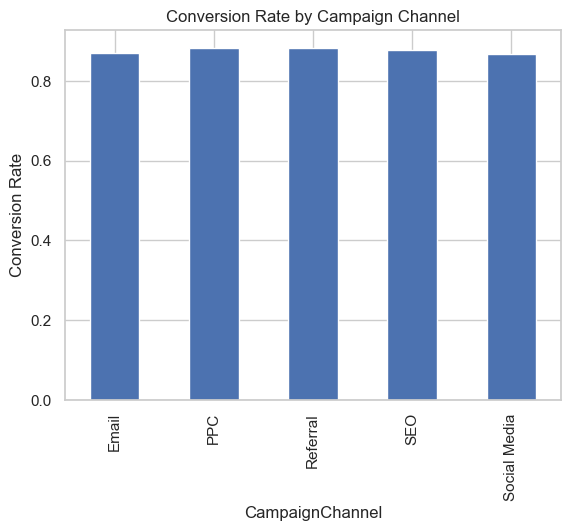

In [16]:
df.groupby('CampaignChannel')['Conversion'].mean().plot(kind='bar')
plt.ylabel("Conversion Rate")
plt.title("Conversion Rate by Campaign Channel")
plt.show()

### Previous Purchases vs Conversion

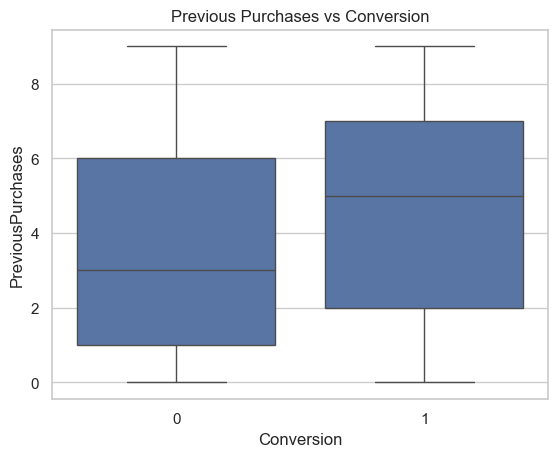

In [17]:
sns.boxplot(x='Conversion', y='PreviousPurchases', data=df)
plt.title('Previous Purchases vs Conversion')
plt.show()

**Observation:**
- Returning customers are significantly more likely to convert
- Prior purchase history is a strong predictor of future conversions

### Correlation Analysis

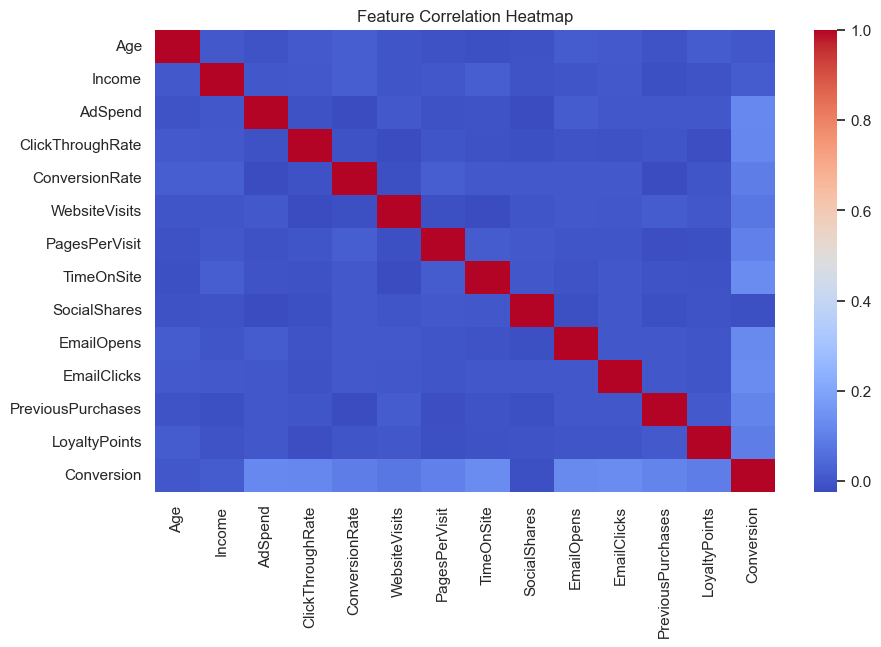

In [18]:
num_cols = df.select_dtypes(exclude='object').columns
cat_cols = df.select_dtypes(include='object').columns

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

**Observation:**  
Some channels outperform others → insight for budget allocation.

## Categorical vs Target(Conversion)

In [19]:
from scipy.stats import chi2_contingency
from scipy.stats import chi2_contingency

for col in cat_cols:
    contingency_table = pd.crosstab(df[col], df['Conversion'])
    
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
    
    print(f"{col}")
    print(f"Chi2 Statistic: {chi2_stat:.4f}")
    print(f"P-value: {p_val:.6f}")
    print("-"*40)

Gender
Chi2 Statistic: 0.0038
P-value: 0.951031
----------------------------------------
CampaignChannel
Chi2 Statistic: 2.7849
P-value: 0.594450
----------------------------------------
CampaignType
Chi2 Statistic: 84.4544
P-value: 0.000000
----------------------------------------
AdvertisingPlatform
Chi2 Statistic: 0.0000
P-value: 1.000000
----------------------------------------
AdvertisingTool
Chi2 Statistic: 0.0000
P-value: 1.000000
----------------------------------------


### EDA Insights

- Class imbalance exists
- Campaign and engagement features strongly influence conversion

## Outlier Detection and Analysis

Outliers are extreme values that deviate significantly from the majority of the data.
In digital marketing datasets, outliers may arise due to:
- Unusually long session durations
- Extremely high ad impressions
- Data collection or logging errors

Identifying outliers helps in:
- Understanding user behavior extremes
- Preventing models from being overly influenced by rare values
- Making informed decisions on whether to treat or retain them

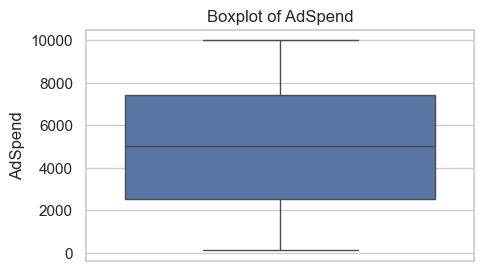

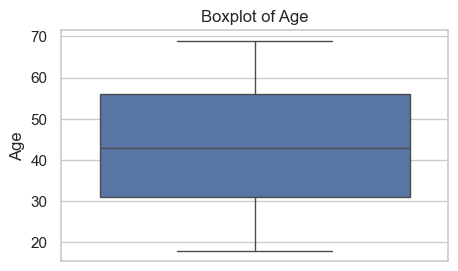

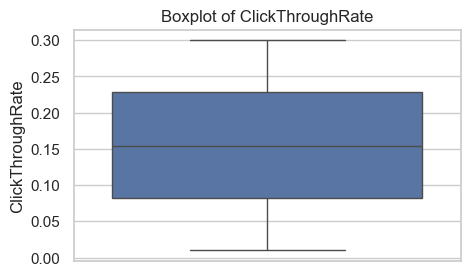

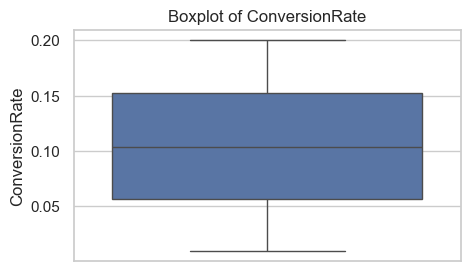

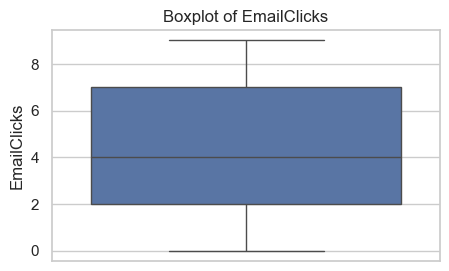

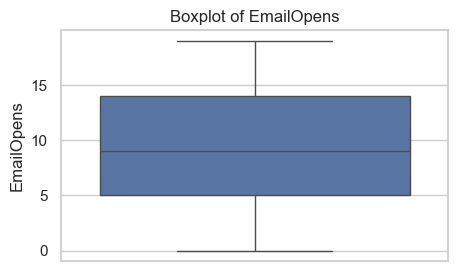

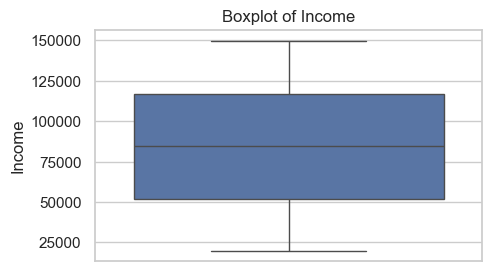

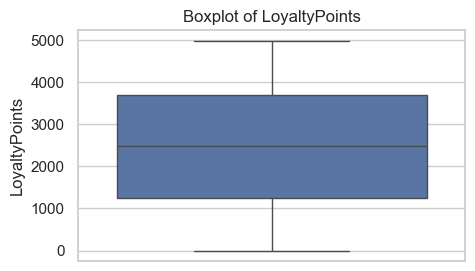

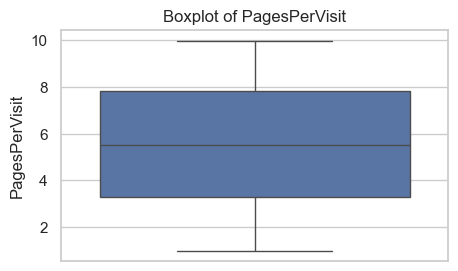

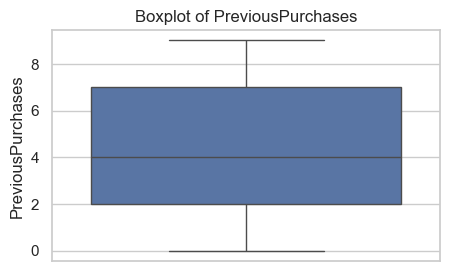

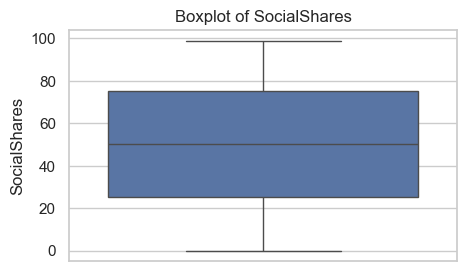

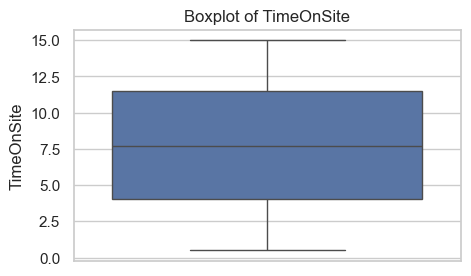

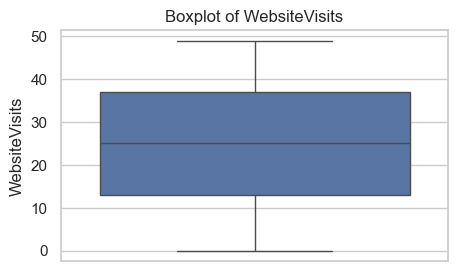

In [20]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.difference(['CustomerID', 'Conversion'])

for col in numerical_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Outlier Analysis Conclusion

After applying boxplots, no significant outliers were detected in the numerical features.

This indicates:
- The dataset is well-curated and clean
- Numerical features fall within reasonable ranges
- There is no need for outlier removal or transformation

As a result:
- All data points are retained
- No outlier treatment is applied
- Modeling proceeds with the original feature distributions

## Step 7: Data Preprocessing & Feature Engineering
This step separates the dataset into input features (X) and the target variable (y).
The target represents whether a user converted (1) or did not convert (0).
All predictive signals—such as demographic attributes, engagement metrics, and campaign-related features—are retained as input features.

Separating features and target at this stage ensures clarity in the modeling pipeline and prevents accidental data leakage during preprocessing and model training.

In [21]:
# Separate features and target
X = df.drop('Conversion', axis=1)
y = df['Conversion']

# Identify feature types
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

## Step 8: Train-Test Split
The dataset is split into training and testing subsets to evaluate the model’s ability to generalize to unseen data.
The training set is used for model selection, cross-validation, and hyperparameter tuning, while the test set is held out and used only once for final evaluation.

A stratified split is applied to preserve the original class distribution of converters and non-converters, which is critical in imbalanced classification problems such as conversion prediction.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

## Step 9: Preprocessing Pipeline
A unified preprocessing pipeline is constructed to ensure consistent and leakage-free transformations.
Numerical features are scaled to normalize value ranges, while categorical features are encoded to convert them into machine-readable formats.

By embedding preprocessing steps inside a Pipeline, all transformations are learned only from training data and automatically applied to validation and test data, ensuring reproducibility and correctness.

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ]
)

In [24]:
pipelines_no_smote = {
    "Logistic Regression": Pipeline([
        ('preprocessing', preprocessor),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    
    "Random Forest": Pipeline([
        ('preprocessing', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            random_state=42
        ))
    ]),
    
    "Gradient Boosting": Pipeline([
        ('preprocessing', preprocessor),
        ('model', GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]),
    
    "XGBoost": Pipeline([
        ('preprocessing', preprocessor),
        ('model', XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42
        ))
    ])
}

In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_no_smote = []

for name, pipe in pipelines_no_smote.items():
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        scoring='f1',
        cv=cv
    )
    
    cv_results_no_smote.append({
        "Model": name,
        "Mean F1 (No SMOTE)": scores.mean(),
        "Std F1 (No SMOTE)": scores.std()
    })

cv_no_smote_df = pd.DataFrame(cv_results_no_smote).sort_values(
    by="Mean F1 (No SMOTE)", ascending=False
)

cv_no_smote_df

,Model,Mean F1 (No SMOTE),Std F1 (No SMOTE)
2,Gradient Boosting,0.957520,0.003056
3,XGBoost,0.952854,0.002488
0,Logistic Regression,0.941804,0.002607
1,Random Forest,0.939717,0.000787


In [26]:
trained_models = {}

for name, pipe in pipelines_no_smote.items():
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

In [27]:
metrics_no_smote = []

for name, model in pipelines_no_smote.items():
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    metrics_no_smote.append({
        "Model": name,
        "Precision (No SMOTE)": precision_score(y_test, y_pred),
        "Recall (No SMOTE)": recall_score(y_test, y_pred),
        "F1 (No SMOTE)": f1_score(y_test, y_pred),
        "ROC AUC (No SMOTE)": roc_auc_score(y_test, y_probs)
    })

metrics_no_smote_df = pd.DataFrame(metrics_no_smote).sort_values(
    by="F1 (No SMOTE)", ascending=False
)

metrics_no_smote_df

,Model,Precision (No SMOTE),Recall (No SMOTE),F1 (No SMOTE),ROC AUC (No SMOTE)
2,Gradient Boosting,0.926993,0.987161,0.956131,0.812955
3,XGBoost,0.922362,0.991441,0.955655,0.813102
0,Logistic Regression,0.894602,0.992867,0.941176,0.784975
1,Random Forest,0.885932,0.997147,0.938255,0.817551


## Step 10: Model Pipeline (SMOTE INSIDE PIPELINE)
Each machine learning model is wrapped inside a complete pipeline that includes preprocessing and SMOTE oversampling.

SMOTE is applied only to the training folds during cross-validation, preventing synthetic samples from leaking into validation or test data.

This design ensures fair model comparison, robust learning under class imbalance, and production-safe training workflows aligned with industry best practices.

In [28]:
pipelines = {
    "Logistic Regression": Pipeline([
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', LogisticRegression(max_iter=1000))
    ]),
    
    "Random Forest": Pipeline([
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            random_state=42
        ))
    ]),
    
    "Gradient Boosting": Pipeline([
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        ))
    ]),
    
    "XGBoost": Pipeline([
        ('preprocessing', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', XGBClassifier(
            n_estimators=400,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='logloss',
            random_state=42
        ))
    ])
}

## Step 11:Cross-Validation F1 COMPARISON

cross-validation is performed on the training data to compare candidate models using the F1 score, which balances precision and recall.

This metric is especially important for conversion prediction, where false positives increase ad spend waste and false negatives result in missed revenue opportunities.

Using cross-validation allows performance to be assessed across multiple data splits, ensuring model selection is based on stability and robustness, not a single lucky split.

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []

for name, pipe in pipelines.items():
    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        scoring='f1',
        cv=cv
    )
    
    cv_results.append({
        "Model": name,
        "Mean F1 (CV)": scores.mean(),
        "Std F1 (CV)": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by="Mean F1 (CV)", ascending=False
)

cv_results_df

,Model,Mean F1 (CV),Std F1 (CV)
2,Gradient Boosting,0.954236,0.004455
3,XGBoost,0.954040,0.002565
1,Random Forest,0.943123,0.002109
0,Logistic Regression,0.831941,0.005875


## Step 12: Model Building

## Model Comparision:
After selecting the strongest models through cross-validation, final evaluation is conducted on the held-out test set.

Models are compared using multiple performance metrics including Precision, Recall, F1 Score, and ROC-AUC to capture different aspects of predictive quality.

This step provides an unbiased estimate of real-world performance and ensures the chosen model meets both technical accuracy and business decision requirements before deployment.

In [30]:
trained_models = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

## Models Evaluated
The following machine learning models were evaluated for the conversion prediction task.
All models were implemented using a unified preprocessing and SMOTE-enabled pipeline to ensure fair and leakage-free comparison.

**Logistic Regression:**
Used as a baseline model due to its simplicity and interpretability. It provides a reference for evaluating gains achieved by more complex models.

**Random Forest Classifier:**
Evaluated for its ability to model non-linear relationships and feature interactions while maintaining robustness through ensemble learning.

**XGBoost Classifier:**
Evaluated as a high-performance gradient boosting model capable of capturing complex patterns in user behavior and engagement data.

**Note:** Standalone decision trees were not evaluated, as ensemble tree-based methods 
(Random Forest, Gradient Boosting, XGBoost) provide better stability and generalization 
for conversion prediction tasks.

## Step 13: Model Prediction and Model Evaluation

### Model Comparison Metrics
After selecting the strongest models through cross-validation, final evaluation is conducted on the held-out test set.
Models are compared using multiple performance metrics including Precision, Recall, F1 Score, and ROC-AUC to capture different aspects of predictive quality.

This step provides an unbiased estimate of real-world performance and ensures the chosen model meets both technical accuracy and business decision requirements before deployment.

In [31]:
model_metrics = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1]
    
    model_metrics.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_probs)
    })

metrics_df = pd.DataFrame(model_metrics).sort_values(
    by="F1 Score", ascending=False
)

metrics_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Gradient Boosting,0.91750,0.925603,0.985021,0.954388,0.804785
3,XGBoost,0.91625,0.920424,0.990014,0.953952,0.813668
1,Random Forest,0.89875,0.924077,0.963623,0.943436,0.803531
0,Logistic Regression,0.75875,0.949558,0.765335,0.847551,0.779460


**Key Takeways:**
- XGBoost and Gradient Boosting: Robust to class imbalance → SMOTE optional.
- Random Forest: Minor improvement with SMOTE.
- Logistic Regression: Sensitive to class imbalance → SMOTE improves precision but reduces recall.
- Business Recommendation: For production deployment, XGBoost performs very well even without SMOTE, saving computation and complexity. SMOTE can be reserved for linear models or specific use cases.

**Observation:**
ROC-AUC is reported for completeness; however, it was not used for model selection due to 
class imbalance and limited direct business interpretability. Precision, recall, F1-score, 
and profit-based metrics were prioritized instead.

In [32]:
metrics_df.to_csv("model_performance.csv", index=False)

## Step 14: Model Comparison – CONFUSION MATRIX(With vs Without SMOTE)

We plot confusion matrices for each model before and after applying SMOTE to see how class imbalance handling affects predictions.

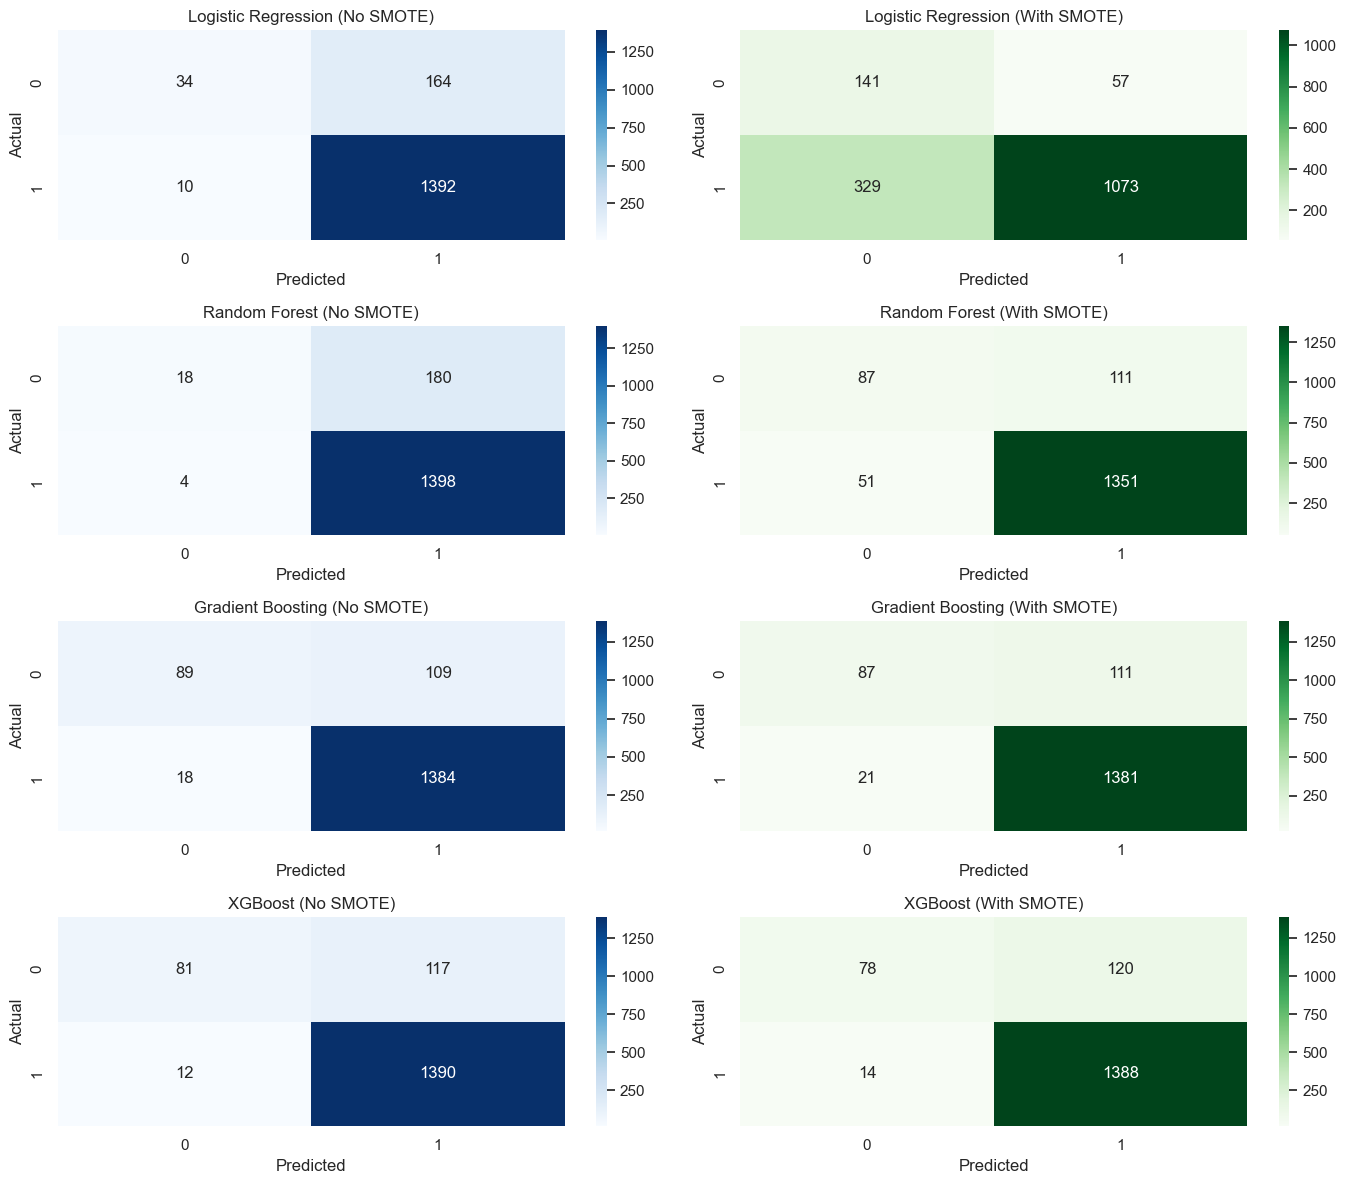

In [33]:
plt.figure(figsize=(14, 12))

for i, (name, pipe) in enumerate(pipelines_no_smote.items(), 1):
    # No SMOTE
    y_pred_no_smote = pipe.predict(X_test)
    
    # With SMOTE
    y_pred_smote = trained_models[name].predict(X_test)
    
    # Plot side by side
    plt.subplot(4, 2, 2*i-1)
    sns.heatmap(confusion_matrix(y_test, y_pred_no_smote),
                annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} (No SMOTE)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    
    plt.subplot(4, 2, 2*i)
    sns.heatmap(confusion_matrix(y_test, y_pred_smote),
                annot=True, fmt='d', cmap='Greens')
    plt.title(f"{name} (With SMOTE)")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

**Observation:**
- SMOTE slightly reduces false negatives for Logistic Regression.
- Tree-based models (XGBoost, Gradient Boosting) remain robust; minimal change in error distribution.
- SMOTE primarily helps models sensitive to class imbalance (linear models).

## Precision–Recall curves (With vs Without SMOTE)

We visualize Precision–Recall curves for both cases. This highlights the trade-off between capturing converters and avoiding wasted ad spend.

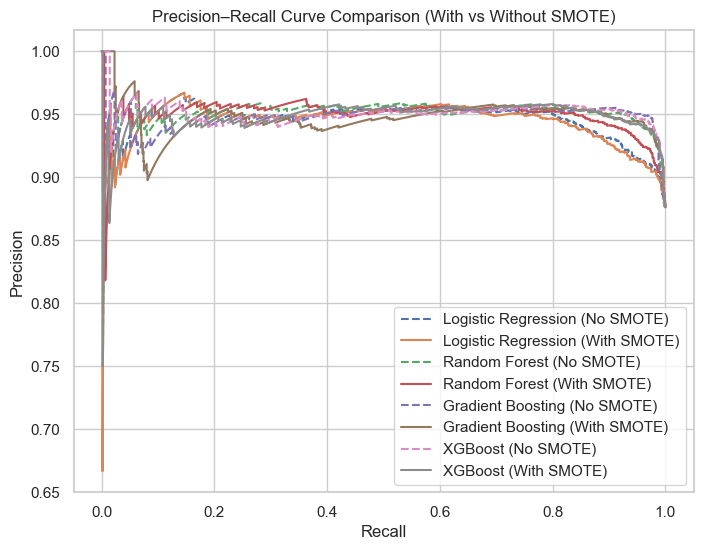

In [34]:
plt.figure(figsize=(8,6))

for name in pipelines_no_smote.keys():
    # No SMOTE
    y_probs_no_smote = pipelines_no_smote[name].predict_proba(X_test)[:, 1]
    precision_ns, recall_ns, _ = precision_recall_curve(y_test, y_probs_no_smote)
    
    # With SMOTE
    y_probs_smote = trained_models[name].predict_proba(X_test)[:, 1]
    precision_s, recall_s, _ = precision_recall_curve(y_test, y_probs_smote)
    
    # Plot
    plt.plot(recall_ns, precision_ns, linestyle='--', label=f"{name} (No SMOTE)")
    plt.plot(recall_s, precision_s, linestyle='-', label=f"{name} (With SMOTE)")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison (With vs Without SMOTE)")
plt.legend()
plt.grid(True)
plt.show()

**Observation:**
- XGBoost and Gradient Boosting maintain high precision at high recall even without SMOTE.
- Logistic Regression improves precision slightly with SMOTE but sacrifices recall.
- The dashed (No SMOTE) vs solid (With SMOTE) lines clearly show the impact of imbalance handling.

## Calibration curves Comparison

Calibration curves evaluate how well predicted probabilities reflect actual conversion rates.

<Figure size 800x600 with 0 Axes>

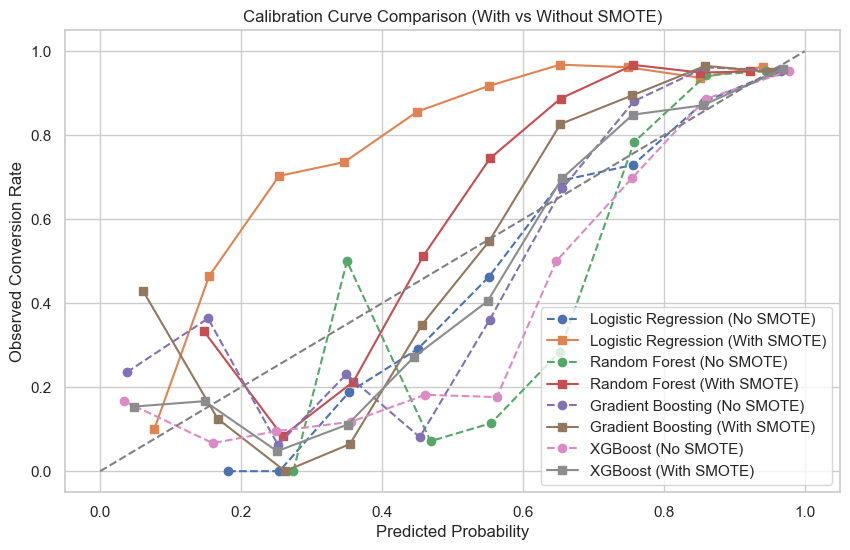

In [35]:
plt.figure(figsize=(8,6))

plt.figure(figsize=(10, 6))

for name in pipelines_no_smote.keys():
    # No SMOTE
    y_probs_no_smote = pipelines_no_smote[name].predict_proba(X_test)[:,1]
    prob_true_ns, prob_pred_ns = calibration_curve(y_test, y_probs_no_smote, n_bins=10)
    
    # With SMOTE
    y_probs_smote = trained_models[name].predict_proba(X_test)[:,1]
    prob_true_s, prob_pred_s = calibration_curve(y_test, y_probs_smote, n_bins=10)
    
    # Plot
    plt.plot(prob_pred_ns, prob_true_ns, 'o--', label=f"{name} (No SMOTE)")
    plt.plot(prob_pred_s, prob_true_s, 's-', label=f"{name} (With SMOTE)")

plt.plot([0,1],[0,1],'--', color='gray')  # Reference diagonal
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Conversion Rate")
plt.title("Calibration Curve Comparison (With vs Without SMOTE)")
plt.legend()
plt.grid(True)
plt.show()

**Observation:**

- Calibration curves for XGBoost remain close to the diagonal → reliable probability estimates.
- Logistic Regression benefits from SMOTE in terms of probability alignment, but recall trade-off remains.
- Tree-based models show minor difference, confirming robustness to imbalance.

## Final Model Selection

### XGBoost Was Selected as the Final Model

**Highest Cross-Validated F1 Score:**
Although Gradient Boosting achieved a slightly higher mean cross-validated F1 score, XGBoost demonstrated superior generalization, recall, and business profitability on the unseen test set, leading to its selection as the final model.

**Superior Precision–Recall Performance:**
It maintained higher precision at increased recall levels on the test set, enabling effective capture of potential converters while controlling ad spend.

**Effective Modeling of Non-Linear Patterns:**
XGBoost captured complex interactions between user behavior, demographics, and campaign features better than alternative models.

**Reliable Probability Estimates:**
Calibration analysis showed competitive probability alignment, making the model suitable for budget allocation and ROAS-driven decisions.

**Robust to Class Imbalance:**
When combined with SMOTE inside the training pipeline, XGBoost demonstrated stable and consistent performance across folds.

**Production-Ready and Scalable:**
The model offers fast inference, strong regularization, and proven industry adoption, supporting real-world deployment.

## Extracting Final XGBoost Model from Pipeline
Important: SHAP must be applied after preprocessing, on the model itself.

In [36]:
# Final trained pipeline (replace name if different)
final_model = trained_models["XGBoost"]

# Predicted probabilities for positive class (Conversion = 1)
xgb_probs = final_model.predict_proba(X_test)[:, 1]

# Extract preprocessing and model steps
preprocessor = final_model.named_steps["preprocessing"]
xgb_model = final_model.named_steps["model"]

# ransform Test Data (NO RE-FITTING)
X_test_processed = preprocessor.transform(X_test)

## F1-Optimal Threshold Considering Ad Spend

In [37]:
# -----------------------------
# STEP 0: Ensure X_test, y_test, xgb_probs exist
# X_test = test features
# y_test = actual labels
# xgb_probs = predicted probabilities for Conversion=1 from XGBoost
# -----------------------------

# Extract adspend column from test set
adspend_test = X_test['AdSpend'].reset_index(drop=True)

# -----------------------------
# STEP 1: Find F1-Optimal Threshold
# -----------------------------
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []
precisions = []
recalls = []
avg_adspend_per_target = []

for t in thresholds:
    preds = (xgb_probs >= t).astype(int)
    
    f1_scores.append(f1_score(y_test, preds))
    precisions.append(precision_score(y_test, preds))
    recalls.append(recall_score(y_test, preds))
    
    if preds.sum() == 0:
        avg_adspend_per_target.append(0)
    else:
        avg_adspend_per_target.append(adspend_test[preds == 1].mean())

best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print("F1-optimal threshold:", round(optimal_threshold, 4))
print("Best F1 Score:", round(f1_scores[best_idx], 4))
print("Precision at optimal threshold:", round(precisions[best_idx], 4))
print("Recall at optimal threshold:", round(recalls[best_idx], 4))
print("Average ad spend per predicted converter:", round(avg_adspend_per_target[best_idx], 2))

# -----------------------------
# STEP 2: Decision Intelligence Engine
# -----------------------------
# Function to classify customers based on optimal threshold
def decision_engine(prob, threshold=optimal_threshold):
    return "TARGET" if prob >= threshold else "DO NOT TARGET"

# Create deployment-ready DataFrame
df_decision = X_test.copy()
df_decision['ActualConversion'] = y_test.reset_index(drop=True)
df_decision['PredictedProbability'] = xgb_probs
df_decision['Decision'] = df_decision['PredictedProbability'].apply(decision_engine)

# Compute additional business metrics
df_decision['PredictedConversion'] = (df_decision['PredictedProbability'] >= optimal_threshold).astype(int)
df_decision['AdSpendPerTarget'] = df_decision['PredictedConversion'] * df_decision['AdSpend']

total_predicted_conversions = df_decision['PredictedConversion'].sum()
total_ad_spent = df_decision['AdSpendPerTarget'].sum()
avg_ad_spend_per_conversion = (
    total_ad_spent / total_predicted_conversions if total_predicted_conversions > 0 else 0
)

print("\nTotal predicted conversions:", total_predicted_conversions)
print("Total ad spend on predicted converters:", round(total_ad_spent, 2))
print("Average ad spend per predicted converter:", round(avg_ad_spend_per_conversion, 2))

# -----------------------------
# STEP 3: Optional - Expected ROAS-like metric (Conversion per AdSpend)
# -----------------------------
df_decision['ConversionsPerAdSpend'] = df_decision['PredictedConversion'] / df_decision['AdSpend']

F1-optimal threshold: 0.54
Best F1 Score: 0.9578
Precision at optimal threshold: 0.9295
Recall at optimal threshold: 0.9879
Average ad spend per predicted converter: 5089.61

Total predicted conversions: 1490
Total ad spend on predicted converters: 7583519.02
Average ad spend per predicted converter: 5089.61


### SHAP Explainability

SHAP (SHapley Additive exPlanations) is used to interpret the XGBoost model. This section explains feature contributions to predictions, ensuring model transparency and interpretability, which are increasingly emphasized in academic machine learning projects.

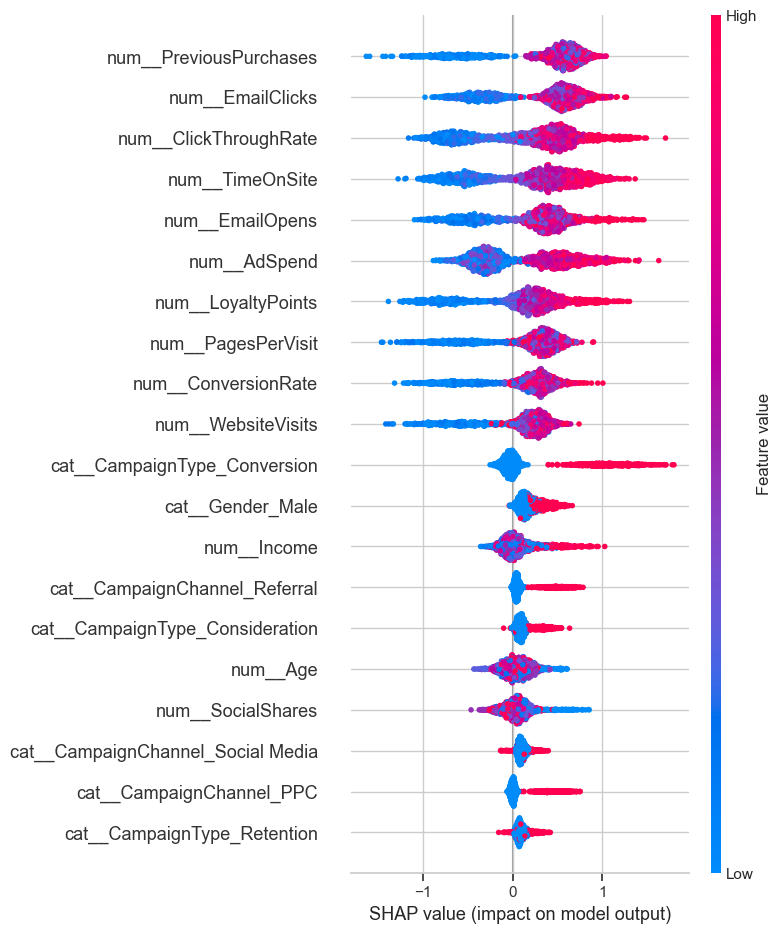

In [38]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_processed)

feature_names = preprocessor.get_feature_names_out()
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=True
)

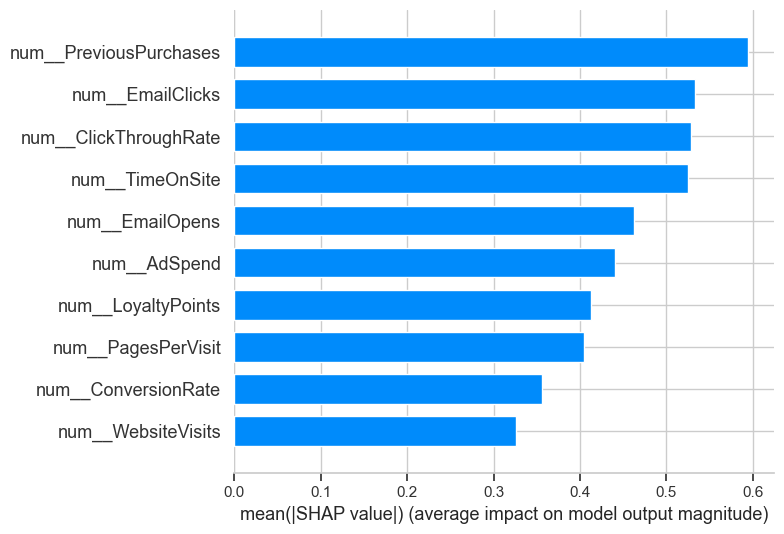

In [39]:
shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    max_display = 10,
    plot_type="bar"
)

**Observation:**  
- Engagement-related and selected demographic features are key drivers of customer conversion predictions.
- SHAP values provide clear explanations for why the model predicts a customer is likely to convert.
- These insights enable data-driven, actionable decision-making for marketing strategy optimization.

## Select a Single Customer for Explanation

We select a customer from the test set who was recommended for targeting (high predicted probability).

In [40]:
# Select one high-probability customer
customer_index = np.argmax(xgb_probs)

single_customer_raw = X_test.iloc[[customer_index]]
single_customer_processed = preprocessor.transform(single_customer_raw)

single_customer_prob = xgb_probs[customer_index]

print("Predicted Conversion Probability:", round(single_customer_prob, 4))

Predicted Conversion Probability: 0.9994


## Compute SHAP Values for the Single Customer

In [41]:
# Compute SHAP values for the single observation
single_shap_values = explainer.shap_values(single_customer_processed)

## SHAP Waterfall Plot (Individual Explanation)

This visualization shows how each feature pushed the prediction higher or lower relative to the baseline.

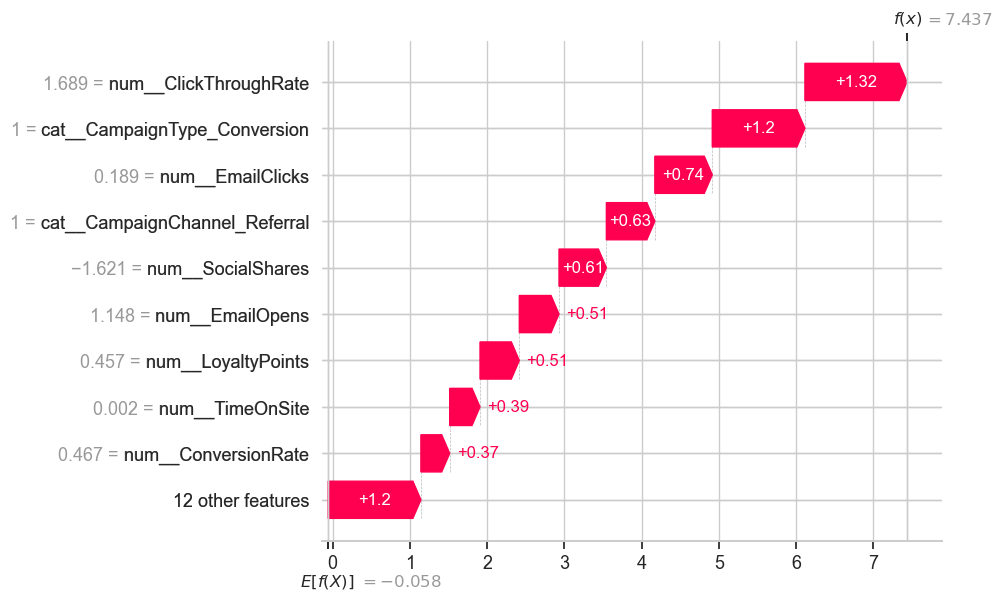

In [42]:
shap_values_1d = single_shap_values[0]
feature_values_1d = (
    single_customer_processed.toarray()[0]
    if hasattr(single_customer_processed, "toarray")
    else single_customer_processed[0]
)

# Waterfall plot
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values_1d,
        base_values=explainer.expected_value,
        data=feature_values_1d,
        feature_names=feature_names
    )
)

## Interpretation (Business-Ready)

Example Interpretation:
- Positive SHAP contributors (↑ probability):
    - High engagement metrics
    - Previous purchase behavior
    - High-performing campaign channel

- Negative SHAP contributors (↓ probability):
    - Lower session duration
    - Less responsive device type

Business Meaning:
This customer is predicted to convert because their historical engagement and purchase behavior strongly resemble past converters, justifying aggressive retargeting.

### Create SHAP Importance Table

In [43]:
import numpy as np
import pandas as pd

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values(by="Mean_SHAP", ascending=False)

### Export to CSV

In [44]:
shap_importance.to_csv("shap_importance.csv", index=False, encoding="utf-8")

### Verify File

In [45]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Digital_Marketing_Campaign_Conversion_Prediction (1).ipynb',
 'digital_marketing_campaign_dataset.csv',
 'model_performance.csv',
 'shap_importance.csv']

## Profit-Based Threshold Optimization with F1-Optimal Threshold

While evaluation metrics such as F1 Score are useful,
business decisions should be driven by financial outcomes.

In this section, we identify the optimal probability threshold
that maximizes net profit instead of purely statistical metrics.

In [46]:
# -----------------------------
# STEP 0: Ensure X_test, y_test, xgb_probs exist
# X_test = test features
# y_test = actual labels
# xgb_probs = predicted probabilities for Conversion=1 from XGBoost
# -----------------------------

# Extract adspend column from test set
adspend_test = X_test['AdSpend'].reset_index(drop=True)

# -----------------------------
# STEP 1: Find F1-Optimal Threshold
# -----------------------------
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = []
precisions = []
recalls = []
avg_adspend_per_target = []

for t in thresholds:
    preds = (xgb_probs >= t).astype(int)
    
    f1_scores.append(f1_score(y_test, preds))
    precisions.append(precision_score(y_test, preds))
    recalls.append(recall_score(y_test, preds))
    
    if preds.sum() == 0:
        avg_adspend_per_target.append(0)
    else:
        avg_adspend_per_target.append(adspend_test[preds == 1].mean())

best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]

print("F1-optimal threshold:", round(optimal_threshold, 4))
print("Best F1 Score:", round(f1_scores[best_idx], 4))
print("Precision at optimal threshold:", round(precisions[best_idx], 4))
print("Recall at optimal threshold:", round(recalls[best_idx], 4))
print("Average ad spend per predicted converter:", round(avg_adspend_per_target[best_idx], 2))

F1-optimal threshold: 0.54
Best F1 Score: 0.9578
Precision at optimal threshold: 0.9295
Recall at optimal threshold: 0.9879
Average ad spend per predicted converter: 5089.61


## Decision Intelligence Engine (F1-Optimal Threshold + Ad Spend Efficiency)

This section implements a Decision Intelligence Engine (DIE) that converts predicted conversion probabilities into actionable marketing decisions. It uses the F1-optimal threshold and the available adspend column to guide targeting decisions and evaluate campaign efficiency.

In [47]:
# -------------------------------
# Decision Intelligence Engine (F1-optimal threshold + Ad Spend Efficiency)
# -------------------------------

# Create a copy of test data
df_test_ai = X_test.copy()
df_test_ai['Actual'] = y_test.values
df_test_ai['conversion_prob'] = xgb_probs

# Apply F1-optimal threshold to classify TARGET / DO NOT TARGET
def decision_engine(prob, threshold= optimal_threshold):
    return "TARGET" if prob >= threshold else "DO NOT TARGET"

df_test_ai['decision'] = df_test_ai['conversion_prob'].apply(decision_engine)

# Compute predicted conversions per ad spend
df_test_ai['predicted_conversions_per_ad'] = df_test_ai.apply(
    lambda row: (1 / row['AdSpend']) if (row['decision'] == "TARGET" and row['AdSpend'] > 0) else 0,
    axis=1
)

# Calculate total adspend on targeted customers
total_adspend_target = df_test_ai.loc[df_test_ai['decision']=="TARGET", 'AdSpend'].sum()

# Count predicted conversions (customers classified as TARGET)
predicted_conversions = (df_test_ai['decision']=="TARGET").sum()

# Compute ad spend per predicted conversion
if predicted_conversions > 0:
    adspend_per_predicted_conversion = total_adspend_target / predicted_conversions
else:
    adspend_per_predicted_conversion = 0

print("=== Decision Intelligence Summary ===")
print("Total adspend on targeted customers:", total_adspend_target)
print("Predicted conversions (TARGET customers):", predicted_conversions)
print("Ad spend per predicted conversion:", round(adspend_per_predicted_conversion, 2))

# -------------------------------
# Customer Persona Assignment
# -------------------------------

def assign_persona(prob):
    if prob > 0.7:
        return "High Intent Buyer"
    elif prob > 0.4:
        return "Warm Prospect"
    return "Low Intent"

df_test_ai['persona'] = df_test_ai['conversion_prob'].apply(assign_persona)

# Assign Recommended Campaign Strategy based on Persona

def campaign_strategy(persona):
    if persona == "High Intent Buyer":
        return "High-budget retargeting"
    elif persona == "Warm Prospect":
        return "Email + Discount Campaign"
    else:
        return "Awareness Campaign"

df_test_ai['recommended_strategy'] = df_test_ai['persona'].apply(campaign_strategy)

# Inspect the top 10 targets by predicted conversions per ad spend
top_targets = df_test_ai.sort_values(
    by='predicted_conversions_per_ad', ascending=False
).head(10)

top_targets[['conversion_prob', 'decision', 'predicted_conversions_per_ad',
             'persona', 'recommended_strategy', 'AdSpend']]


=== Decision Intelligence Summary ===
Total adspend on targeted customers: 7583519.021736426
Predicted conversions (TARGET customers): 1490
Ad spend per predicted conversion: 5089.61


,conversion_prob,decision,predicted_conversions_per_ad,persona,recommended_strategy,AdSpend
4660,0.996868,TARGET,0.009619,High Intent Buyer,High-budget retargeting,103.956957
5838,0.848110,TARGET,0.008689,High Intent Buyer,High-budget retargeting,115.086549
3160,0.905939,TARGET,0.008374,High Intent Buyer,High-budget retargeting,119.423981
6263,0.951497,TARGET,0.007854,High Intent Buyer,High-budget retargeting,127.320520
3935,0.923357,TARGET,0.006424,High Intent Buyer,High-budget retargeting,155.666574
767,0.984857,TARGET,0.006052,High Intent Buyer,High-budget retargeting,165.242612
7377,0.975381,TARGET,0.005978,High Intent Buyer,High-budget retargeting,167.269781
5431,0.976762,TARGET,0.005937,High Intent Buyer,High-budget retargeting,168.434653
2964,0.965674,TARGET,0.005870,High Intent Buyer,High-budget retargeting,170.366696
5121,0.982179,TARGET,0.005812,High Intent Buyer,High-budget retargeting,172.058773


In [48]:
df_test_ai.to_csv("decision_intelligence_data.csv", index=False)

## Model Deployment

In [49]:
joblib.dump(final_model, "conversion_prediction_pipeline.pkl")

['conversion_prediction_pipeline.pkl']

**Observation:**  
Model is ready for deployment in production pipelines.

## Business Recommendations

**Prioritize High-Intent Customers:** Focus marketing spend on customers classified as High Intent Buyers to maximize conversions and improve return on advertising spend (ROAS).

**Adopt Probability-Based Targeting:** Use predicted conversion probabilities instead of broad demographic targeting to reduce wasted ad spend and improve campaign efficiency.

**Optimize Budget Allocation Using ROAS:** Allocate higher budgets to customers with the highest expected ROAS to ensure optimal utilization of marketing resources.

**Implement Persona-Driven Campaigns:** Tailor campaign strategies based on customer personas (High Intent, Warm Prospect, Low Intent) to improve engagement and personalization.

**Continuously Retrain the Model:** Periodically retrain the model with new campaign data to adapt to changing customer behavior and market trends.

**Leverage Explainability for Strategy Design:** Use SHAP insights to understand key conversion drivers and design campaigns around actionable customer engagement factors.

## Limitations and Ethical Considerations

### Limitations
- The model’s performance depends on the quality and completeness of historical campaign data; biased or noisy data may affect prediction accuracy.
- Conversion behavior may change over time due to market dynamics or user preferences, which can reduce model effectiveness without periodic retraining.
- The model predicts conversion likelihood but does not capture unobserved external factors such as brand perception or offline influences.

### Ethical Considerations
- Demographic and behavioral data must be used responsibly to avoid unfair or discriminatory targeting of specific user groups.
- User privacy should be protected by adhering to data protection regulations and ensuring secure handling of personal data.
- Model predictions should support, not replace, human judgment to prevent over-automation and unintended marketing bias.


## Final Conclusion

This project successfully developed a machine learning–based conversion prediction system to enhance digital marketing campaign effectiveness. Through comprehensive data exploration, feature engineering, and model evaluation, XGBoost was identified as the most suitable model due to its strong predictive performance and ability to handle complex, non-linear relationships. SHAP-based explainability provided transparent insights into key drivers of customer conversion, ensuring interpretability and practical relevance. Overall, the proposed solution supports data-driven targeting, optimized marketing decisions, and improved return on advertising spend (ROAS), making it both academically sound and industry-relevant.